In [1]:
import sys
sys.path.append('/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/')
from pathlib import Path
from meteofetch import Arome0025
import get_meteo_dataset
import generate_maps

%load_ext autoreload
%autoreload 2

In [15]:
datasets = get_meteo_dataset.get_latest_forecast(
    'SP2', 
    Path('/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs'),
    fields=['lcc', 'mcc', 'hcc'])


Files already up-to-date: ['/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__SP2__00H06H__2026-05-09T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__SP2__07H12H__2026-05-09T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__SP2__13H18H__2026-05-09T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__SP2__19H24H__2026-05-09T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__SP2__25H30H__2026-05-09T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__SP2__31H36H__2026-05-09T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__SP2__37H42H__2026-05-09T09-00-00Z.grib2', '/Users/qubo/L

/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


In [16]:
import xarray as xr

# Example: Load a dataset
da = datasets["lcc"]  # Temperature at 2 meters

# Check coordinates
print(da.coords)  # Shows latitude, longitude, time, etc.

# Check if the grid is regular
lat_diff = da.latitude.diff(dim="latitude").mean().values
lon_diff = da.longitude.diff(dim="longitude").mean().values
print(f"Average lat spacing: {lat_diff}, lon spacing: {lon_diff}")

Coordinates:
  * time         (time) datetime64[ns] 408B 2026-05-09T10:00:00 ... 2026-05-1...
    step         (time) timedelta64[ns] 408B 01:00:00 ... 2 days 03:00:00
  * latitude     (latitude) float64 6kB 37.5 37.53 37.55 ... 55.35 55.38 55.4
  * longitude    (longitude) float64 9kB -12.0 -11.97 -11.95 ... 15.98 16.0
    surface      float64 8B 0.0
    spatial_ref  int64 8B 0
Average lat spacing: 0.024999999999999998, lon spacing: 0.025


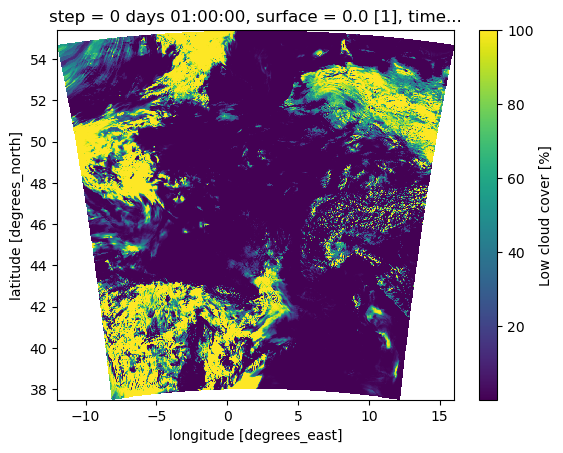

In [17]:
layer = da.isel(time=0)
layer.plot()

/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: Runt

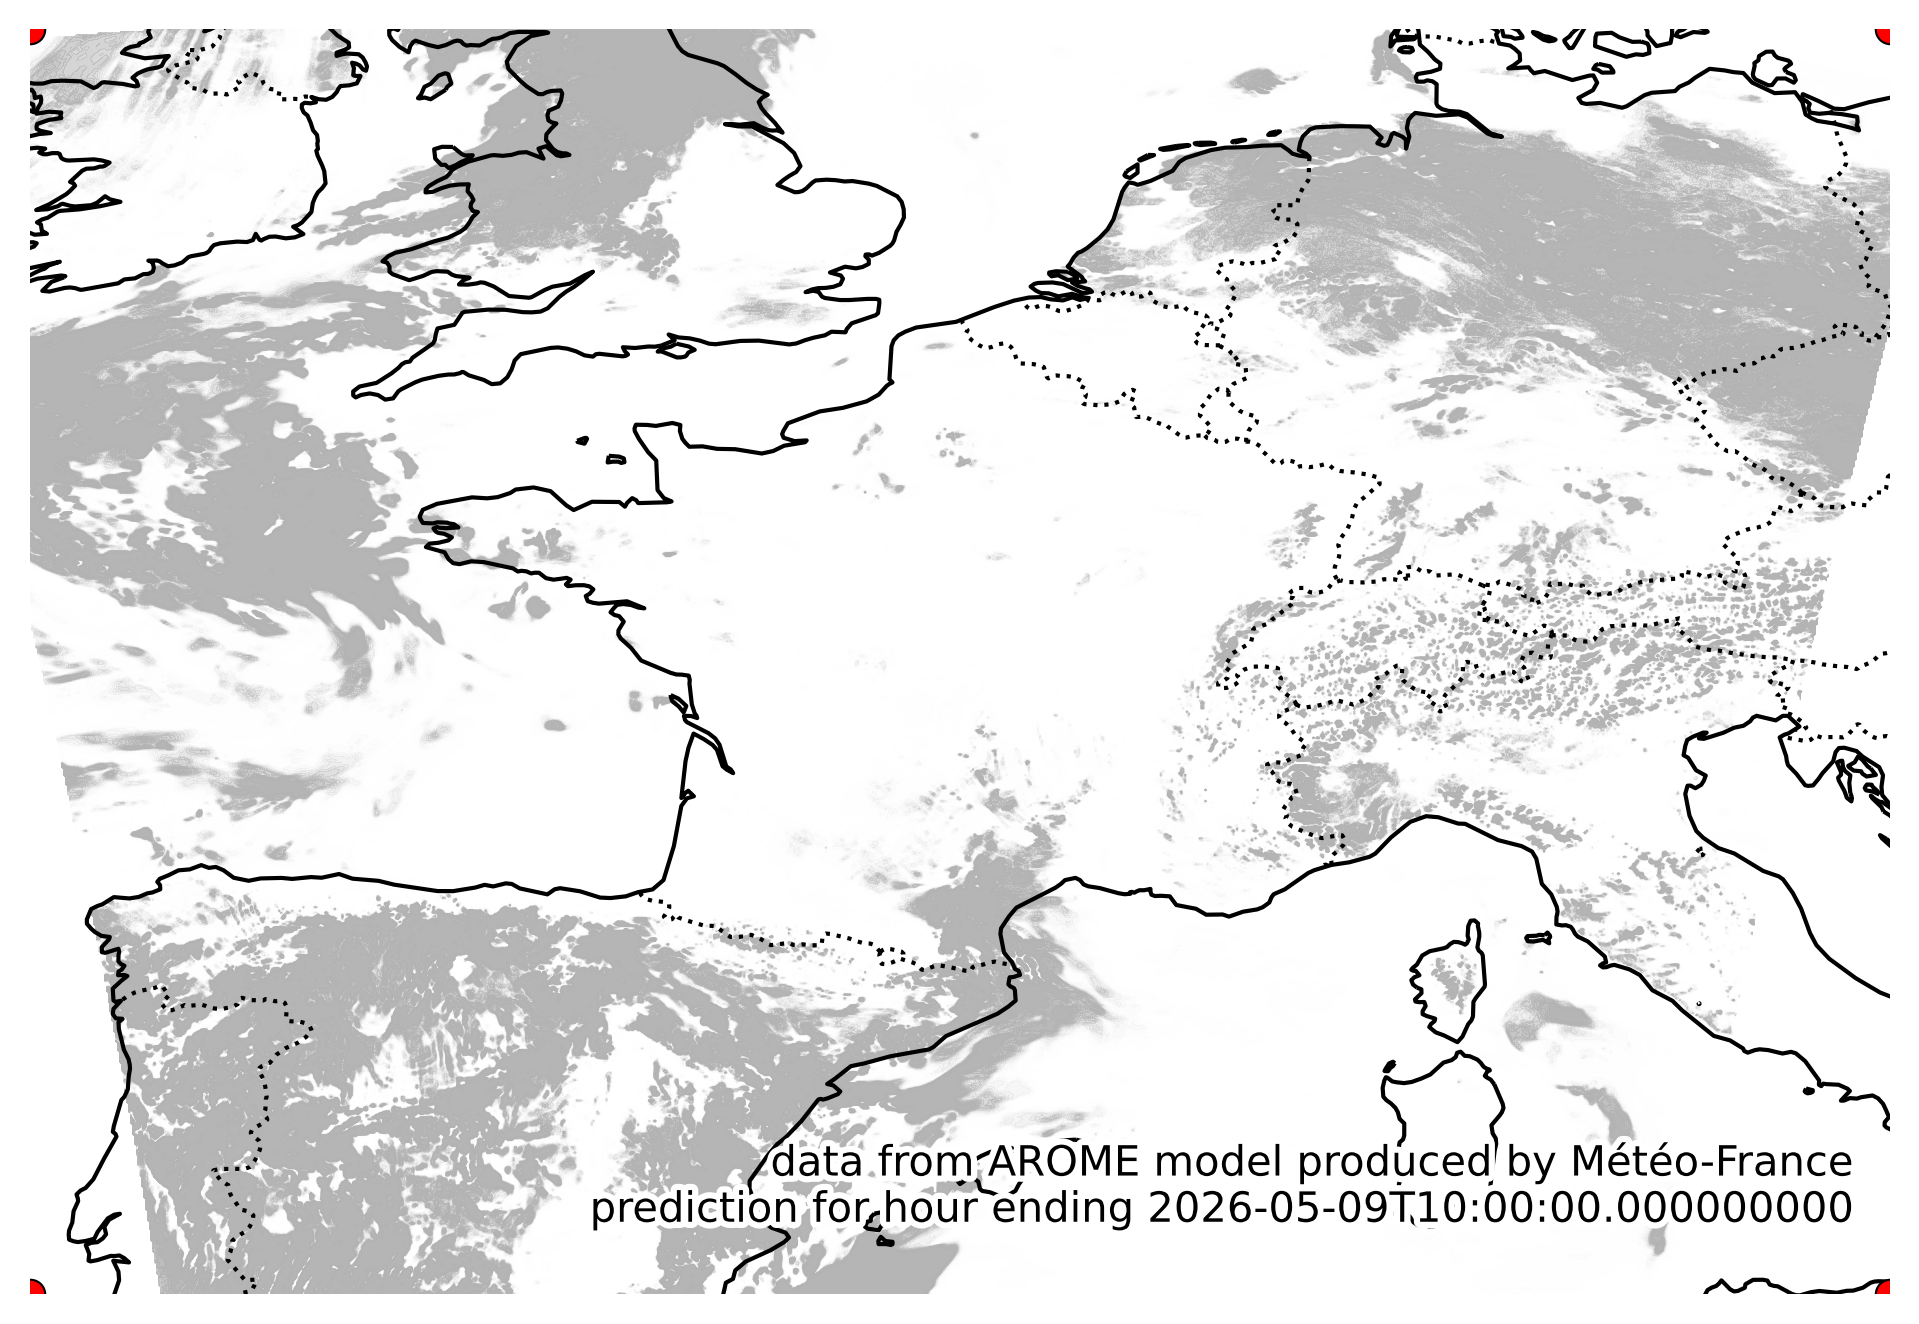

In [22]:
generate_maps.plot_layer_to_png(
    layer=layer,
    output_path=Path('/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/cloud.png'),
    show=True,
    levels=20,
    vmin=0.01,

)